# Model Training & Baseline Results

### Training Setup
We fine-tuned a pretrained T5-small model on the SCAN dataset. The model learns to map natural language commands to action sequences.

**Training Configuration:**
- Model: T5-small
- Optimizer: Adam (lr=1e-4)
- Batch size: 64
- Epochs: 10 (with early stopping)

### Training Curves

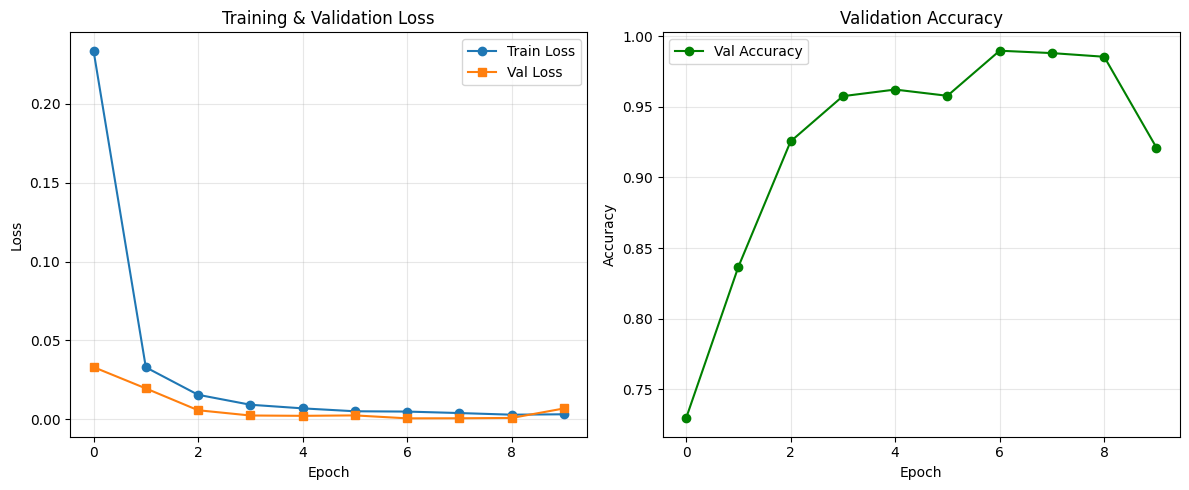

Final validation accuracy: 92.11%


In [5]:
import json
import matplotlib.pyplot as plt

# Load training history
with open('../results/models/training_history.json') as f:
    history = json.load(f)

plt.figure(figsize=(12, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', marker='o')
plt.plot(history['val_loss'], label='Val Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(history['val_accuracy'], label='Val Accuracy', marker='o', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/baseline_performance/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Final validation accuracy: {history['val_accuracy'][-1]:.2%}")

### Baseline Performance Across Splits

Evaluate on different test sets to understand generalization:

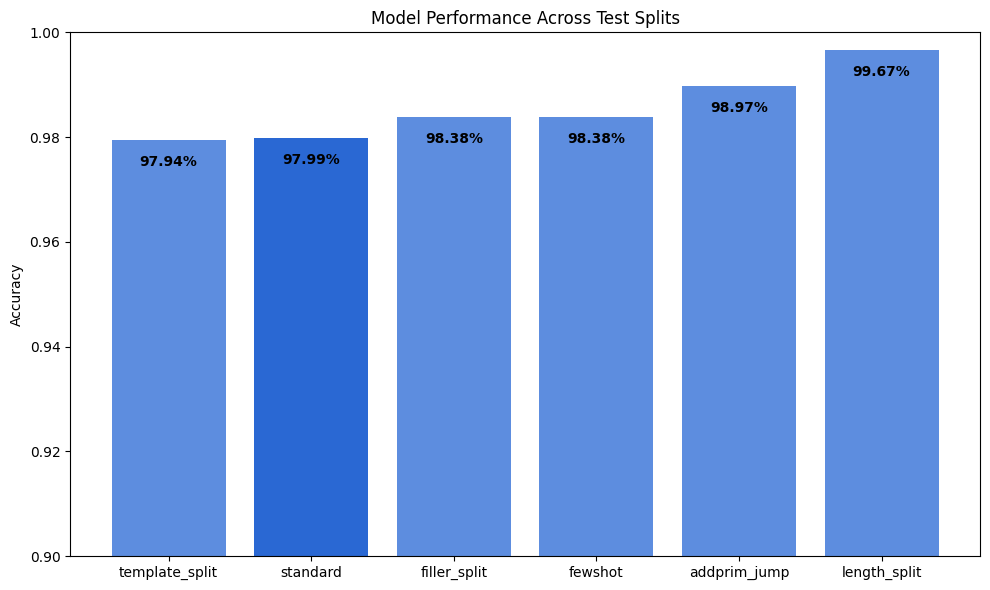

In [26]:
import pandas as pd

# Load evaluation results
results = pd.read_csv('../results/baseline_performance/split_evaluation.csv')
results = results.sort_values(by='accuracy')

plt.figure(figsize=(10, 6))
plt.bar(results['split'], results['accuracy'], color=['#2A68D3' if split_name == 'standard' else '#5D8DDF' for split_name in results['split']])
plt.ylabel('Accuracy')
plt.title('Model Performance Across Test Splits')
plt.ylim([0.9, 1.0])
for i, v in enumerate(results['accuracy']):
    plt.text(i, v - 0.005, f'{v:.2%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/baseline_performance/baseline_performance.png', dpi=150, bbox_inches='tight')
plt.show()